### Homework 7 — *College Student Success Analytics*
**Topics:** Pandas, NumPy, Matplotlib  

**Goal:**  For this homework, I want you to practices with pandas, numpy, and matplotlib but I want you also to practice figuring out what the data is telling us!  So, story-telling is a learning goal:)  

Two synthetic datasets describe **250 fictional Rhodes students**. 

| File | Rows | Description |
|------|------|-------------|
| `student_academic.csv` | 250 | One row per student: GPA, credits, study hours, attendance, etc. |
| `student_activities.csv` | 0–650 | One row per *activity* a student joins (0–3 per student) with hours/week & leadership flag |

---
## Task
The Dean of Students wants to know which factors predict academic success and whether co‑curricular involvement helps or hurts. Produce a short analytics report (and this reproducible notebook) that answers her questions.

---
## Part A — Data Wrangling *(15 pts)*
1. **Load & inspect** both CSVs (done above). Show shape and `dtypes`.
2. **Handle missing values** (~5 % already inserted). Choose a strategy to fix it **and justify it in the comments**.
3. **Add Three Columns** (GPA_change, StudyIntensity, AttendanceFlag) to the data frame calculated as follows:
```text
GPA_change          = GPA_Sem2 – GPA_Sem1
StudyIntensity = Hours_Study / Credits_Enrolled
AttendanceFlag = 1 if AttendanceRate ≥ 0.90 else 0
```


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#1 

academic_df = pd.read_csv('student_academic.csv')
print("Academic Data Shape:", academic_df.shape)
print("\nAcademic Data Types:")
print(academic_df.dtypes)
print("\nAcademic Data - First 5 rows:")
print(academic_df.head())

activities_df = pd.read_csv('student_activities.csv')
print("\nActivities Data Shape:", activities_df.shape)
print("\nActivities Data Types:")
print(activities_df.dtypes)
print("\nActivities Data - First 5 rows:")
print(activities_df.head())

#2
# For Sem1: Fill with the mean of the same major and class year
# For sem2: Same approach as GPA_Sem1
# for HoursStudy: Fill with the median study hours for the same major
# For Attenrate: Use the median of the db

print("\nMissing values in academic_df:")
print(academic_df.isnull().sum())
print("\nMissing values percentage in academic_df:")
print(academic_df.isnull().mean().round(4) * 100)
print("\nMissing values in activities_df:")
print(activities_df.isnull().sum())


academic_df_clean = academic_df.copy()


academic_df_clean['GPA_Sem1'] = academic_df_clean.groupby(['Major', 'ClassYear'])['GPA_Sem1'].transform(
    lambda x: x.fillna(x.mean()))
academic_df_clean['GPA_Sem1'] = academic_df_clean['GPA_Sem1'].fillna(academic_df_clean['GPA_Sem1'].mean())

academic_df_clean['GPA_Sem2'] = academic_df_clean.groupby(['Major', 'ClassYear'])['GPA_Sem2'].transform(
    lambda x: x.fillna(x.mean()))
academic_df_clean['GPA_Sem2'] = academic_df_clean['GPA_Sem2'].fillna(academic_df_clean['GPA_Sem2'].mean())

academic_df_clean['Hours_Study'] = academic_df_clean.groupby('Major')['Hours_Study'].transform(
    lambda x: x.fillna(x.median()))
academic_df_clean['Hours_Study'] = academic_df_clean['Hours_Study'].fillna(academic_df_clean['Hours_Study'].median())

academic_df_clean['AttendanceRate'] = academic_df_clean['AttendanceRate'].fillna(academic_df_clean['AttendanceRate'].median())
print("Missing values after cleaning:")
print(academic_df_clean.isnull().sum())

#3

academic_df_clean['GPA_change'] = academic_df_clean['GPA_Sem2'] - academic_df_clean['GPA_Sem1']
academic_df_clean['StudyIntensity'] = academic_df_clean['Hours_Study'] / academic_df_clean['Credits_Enrolled']
academic_df_clean['AttendanceFlag'] = (academic_df_clean['AttendanceRate'] >= 0.90).astype(int)
print("\nDataFrame with new columns (first 5 rows):")
print(academic_df_clean[['StudentID', 'GPA_Sem1', 'GPA_Sem2', 'GPA_change', 'StudyIntensity', 'AttendanceFlag']].head())




Academic Data Shape: (250, 9)

Academic Data Types:
StudentID             int64
Major                object
ClassYear            object
GPA_Sem1            float64
GPA_Sem2            float64
Credits_Enrolled      int64
Hours_Study         float64
AttendanceRate      float64
Scholarship          object
dtype: object

Academic Data - First 5 rows:
   StudentID       Major  ClassYear  GPA_Sem1  GPA_Sem2  Credits_Enrolled  \
0       1001  Psychology   Freshman      3.86      3.68                14   
1       1002     English     Senior      3.01      3.29                13   
2       1003   Economics     Senior      3.23      3.23                15   
3       1004     English  Sophomore      2.96      2.85                16   
4       1005     English     Senior      2.93      2.92                12   

   Hours_Study  AttendanceRate Scholarship  
0         12.0            0.98          No  
1         24.0            0.76          No  
2         33.0            0.89          No  
3       

---
## Part B — Exploratory Analyses *(55 pts)*
The difficulty of this problem that the data is contained in two different data sets.  They are connected by StudentID.  You'll need to google this and figure out how to *merge* the data.   Make sure you do it correctly.

| # | Question | Pts |
|---|----------|-----|
| 1 | **GPA shift.** Distribution of `GPA_change`. Print out the top 10 improvers. | 8 |
| 2 | **Study habits.** Pearson correlation between `StudyIntensity` and `GPA_Sem2`; Visualize with scatter and print out the Pearson correlation (in our notes).    | 8 |
| 3 | **Scholarships.** Mean & SD of `GPA_Sem2` for scholarship vs non‑scholarship.  Visualize this with box plot. | 6 |
| 4 | **Attendance.** Compute the average `GPA_Sem2` for `AttendanceFlag` = 1 vs 0. Visualize this with a bar chart. | 6 |
| 5 | **Activity load.** Compute total `Activity_Hours`; plot vs `GPA_Sem2`. | 6 |
| 6 | **Leadership.** Does *any* leadership role correspond to higher GPA?  Plot this with box plot (include average and std for each leadership role).  You might have to groupby...| 7 |
| 7 | **Major comparison.** For every major: mean GPA, mean study hours, scholarship %. Print out  and Visualize with a grouped bar chart. | 8 |
| 8 | **Predictive index.** Calculate the (z‑score) GPA (looking back at our class notes), attendance, study hours; Call this variable `SuccessScore`; list top 15. | 6 |


Top 10 GPA Improvers:
     StudentID             Major  ClassYear  GPA_Sem1  GPA_Sem2  GPA_change
71        1072           English     Junior     1.850      3.30       1.450
202       1203  Computer Science     Junior     2.470      3.89       1.420
92        1093         Economics     Junior     2.500      3.88       1.380
204       1205        Psychology     Senior     2.330      3.70       1.370
222       1223         Economics  Sophomore     2.340      3.58       1.240
193       1194           Biology   Freshman     2.450      3.61       1.160
178       1179           English   Freshman     2.160      3.29       1.130
34        1035         Economics     Senior     2.580      3.70       1.120
62        1063           English     Junior     2.220      3.27       1.050
12        1013           English   Freshman     2.958      4.00       1.042
Pearson correlation between StudyIntensity and GPA_Sem2: -0.1046


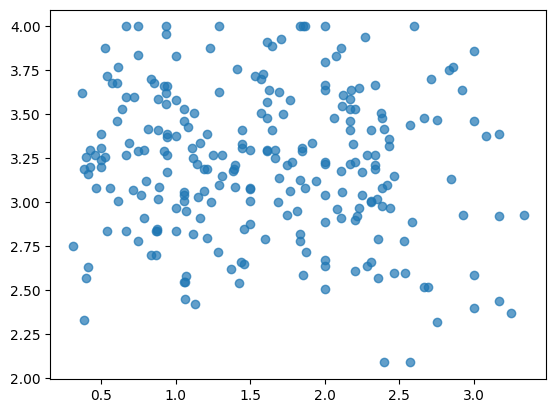


GPA_Sem2 Statistics by Scholarship Status:
  Scholarship      mean       std
0          No  3.184309  0.420658
1         Yes  3.267370  0.397191


/var/folders/6v/708k2j617490_wrb3bj_j_780000gn/T/ipykernel_60924/147386607.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups.groups.keys())


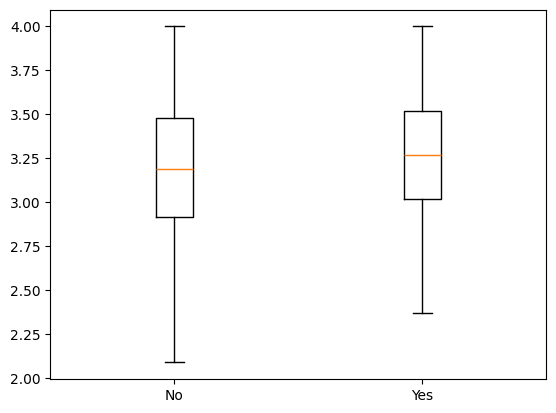


Average GPA_Sem2 by Attendance Flag:
   AttendanceFlag  GPA_Sem2
0               0  3.246455
1               1  3.176804


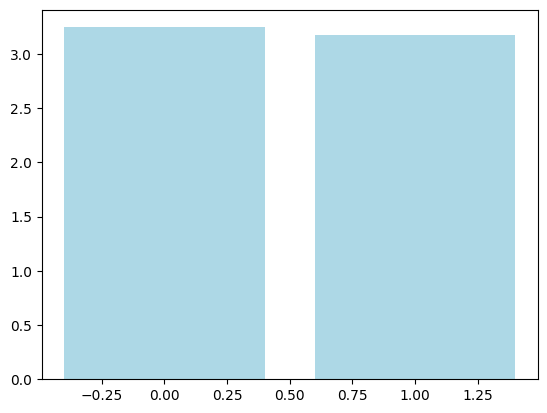

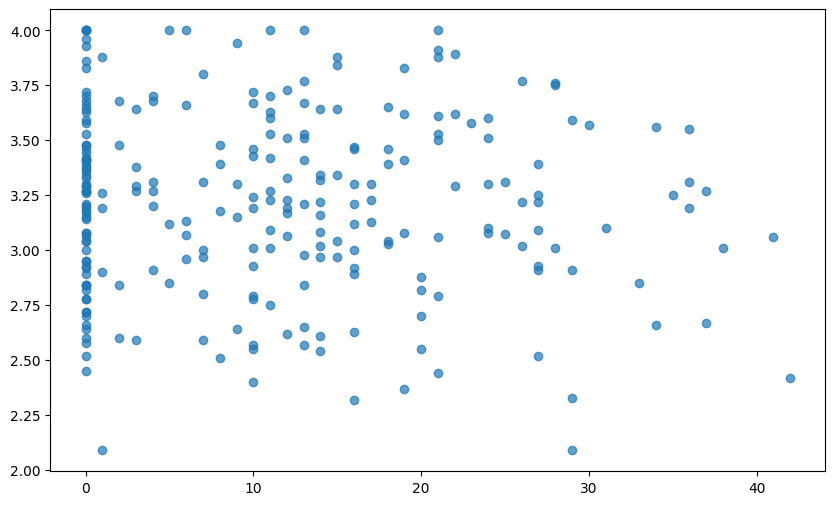


GPA_Sem2 Statistics by Leadership Status:
   Has_Leadership      mean       std
0   No Leadership  3.223810  0.416574
1  Has Leadership  3.205248  0.407749


/var/folders/6v/708k2j617490_wrb3bj_j_780000gn/T/ipykernel_60924/147386607.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups.groups.keys())


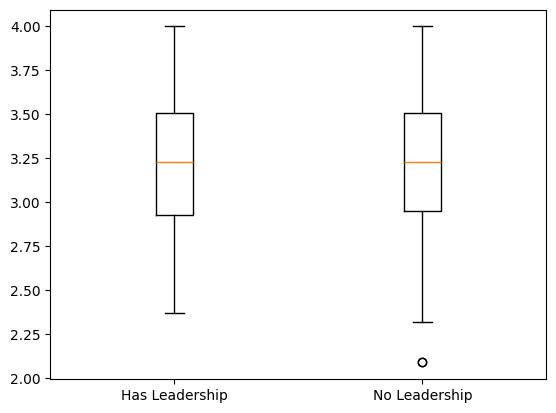


Major Comparison Statistics:
              Major  Mean_GPA  Mean_Study_Hours  Scholarship_Pct
0           Biology  3.306032         25.261905        33.333333
1  Computer Science  3.196526         23.250000        41.071429
2         Economics  3.166253         22.156863        33.333333
3           English  3.252589         23.051282        41.025641
4        Psychology  3.195351         22.951613        46.774194


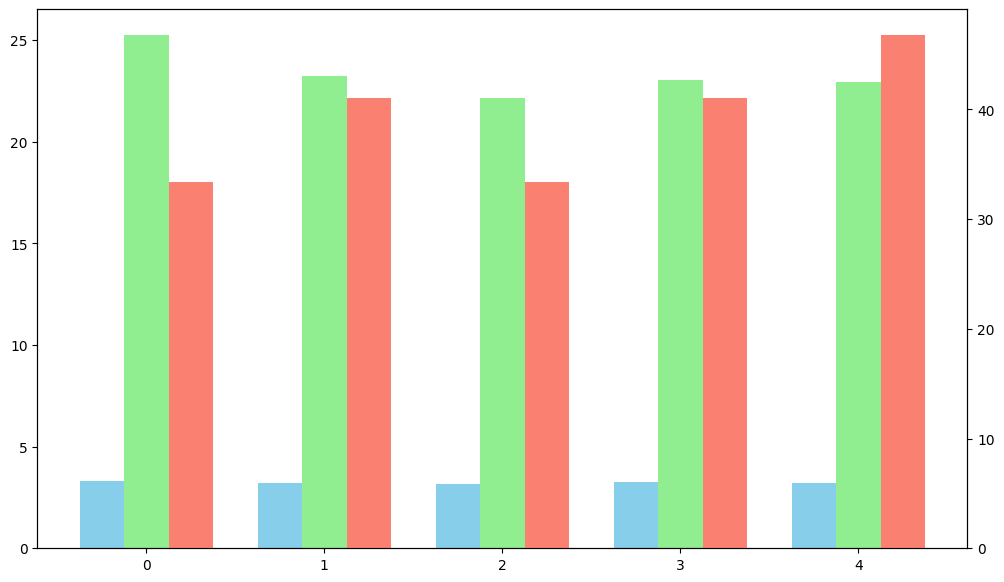


Top 15 Students by Success Score:
     StudentID             Major  ClassYear  GPA_Sem2  AttendanceRate  \
12        1013           English   Freshman      4.00            0.95   
33        1034  Computer Science     Senior      3.91            0.99   
126       1127           English  Sophomore      3.46            0.99   
94        1095  Computer Science     Senior      3.53            0.96   
41        1042  Computer Science     Senior      3.51            0.97   
143       1144        Psychology   Freshman      3.46            0.97   
179       1180  Computer Science     Senior      3.93            0.95   
66        1067           Biology     Senior      3.41            0.98   
10        1011        Psychology   Freshman      3.83            0.97   
59        1060           Biology  Sophomore      3.80            0.98   
92        1093         Economics     Junior      3.88            0.88   
34        1035         Economics     Senior      3.70            0.91   
181       1182  

In [18]:

#0 (merge)
activity_counts = activities_df.groupby('StudentID').size().reset_index(name='Activity_Count')
activity_hours = activities_df.groupby('StudentID')['HoursPerWeek'].sum().reset_index(name='Activity_Hours')
leadership = activities_df[activities_df['LeadershipRole'] == 'Yes'].groupby('StudentID').size().reset_index(name='Leadership_Count')
leadership['Has_Leadership'] = 1

activities_summary = pd.merge(activity_counts, activity_hours, on='StudentID', how='outer')
activities_summary = pd.merge(activities_summary, leadership[['StudentID', 'Has_Leadership']], on='StudentID', how='left')
activities_summary['Has_Leadership'] = activities_summary['Has_Leadership'].fillna(0).astype(int)

student_df = pd.merge(academic_df_clean, activities_summary, on='StudentID', how='left')
student_df['Activity_Count'] = student_df['Activity_Count'].fillna(0)
student_df['Activity_Hours'] = student_df['Activity_Hours'].fillna(0)
student_df['Has_Leadership'] = student_df['Has_Leadership'].fillna(0)

#1
top_improvers = student_df.sort_values(by='GPA_change', ascending=False).head(10)
print("\nTop 10 GPA Improvers:")
print(top_improvers[['StudentID', 'Major', 'ClassYear', 'GPA_Sem1', 'GPA_Sem2', 'GPA_change']])

#2
correlation = student_df['StudyIntensity'].corr(student_df['GPA_Sem2'])
print(f"Pearson correlation between StudyIntensity and GPA_Sem2: {correlation:.4f}")

plt.scatter(student_df['StudyIntensity'], student_df['GPA_Sem2'], alpha=0.7)
plt.show()

#3
scholarship_stats = student_df.groupby('Scholarship')['GPA_Sem2'].agg(['mean', 'std']).reset_index()
print("\nGPA_Sem2 Statistics by Scholarship Status:")
print(scholarship_stats)

groups = student_df.groupby('Scholarship')['GPA_Sem2']
data = [group for name, group in groups]
plt.boxplot(data, labels=groups.groups.keys())
plt.show()

#4
attendance_gpa = student_df.groupby('AttendanceFlag')['GPA_Sem2'].mean().reset_index()
print("\nAverage GPA_Sem2 by Attendance Flag:")
print(attendance_gpa)

plt.bar(attendance_gpa['AttendanceFlag'], attendance_gpa['GPA_Sem2'], color='lightblue')
plt.show()

#5
plt.figure(figsize=(10, 6))
plt.scatter(student_df['Activity_Hours'], student_df['GPA_Sem2'], alpha=0.7)
activity_corr = student_df['Activity_Hours'].corr(student_df['GPA_Sem2'])
plt.show()

#6
leadership_stats = student_df.groupby('Has_Leadership')['GPA_Sem2'].agg(['mean', 'std']).reset_index()
leadership_stats['Has_Leadership'] = leadership_stats['Has_Leadership'].map({0: 'No Leadership', 1: 'Has Leadership'})
print("\nGPA_Sem2 Statistics by Leadership Status:")
print(leadership_stats)
student_df['Leadership_Status'] = student_df['Has_Leadership'].map({0: 'No Leadership', 1: 'Has Leadership'})
groups = student_df.groupby('Leadership_Status')['GPA_Sem2']
data = [group for name, group in groups]
plt.boxplot(data, labels=groups.groups.keys())
plt.show()

#7
major_stats = student_df.groupby('Major').agg(
    Mean_GPA=('GPA_Sem2', 'mean'),
    Mean_Study_Hours=('Hours_Study', 'mean'),
    Scholarship_Pct=('Scholarship', lambda x: (x == 'Yes').mean() * 100)
).reset_index()

print("\nMajor Comparison Statistics:")
print(major_stats)
x = np.arange(len(major_stats))
width = 0.25
fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()
ax1.bar(x - width, major_stats['Mean_GPA'], width, label='Mean GPA', color='skyblue')
ax1.bar(x, major_stats['Mean_Study_Hours'], width, label='Mean Study Hours', color='lightgreen')
ax2.bar(x + width, major_stats['Scholarship_Pct'], width, label='Scholarship %', color='salmon')




plt.show()

#8
student_df['GPA_z'] = (student_df['GPA_Sem2'] - student_df['GPA_Sem2'].mean()) / student_df['GPA_Sem2'].std()
student_df['Attendance_z'] = (student_df['AttendanceRate'] - student_df['AttendanceRate'].mean()) / student_df['AttendanceRate'].std()
student_df['StudyHours_z'] = (student_df['Hours_Study'] - student_df['Hours_Study'].mean()) / student_df['Hours_Study'].std()
student_df['SuccessScore'] = (student_df['GPA_z'] + student_df['Attendance_z'] + student_df['StudyHours_z']) / 3

top_success = student_df.sort_values(by='SuccessScore', ascending=False).head(15)
print("\nTop 15 Students by Success Score:")
print(top_success[['StudentID', 'Major', 'ClassYear', 'GPA_Sem2', 'AttendanceRate', 'Hours_Study', 'SuccessScore']])

---
## Part C — Communication *(15 pts)*

* Explain two actionable insights from your data
* Point to the data that seems to be the most powerful.
* The discussion here should be at least 200 words.
* Your explanation should be in markdown.  Modify the markdown cell below.  
 

## two insights I made while parsing the data

English major students had biggest gpa increases
bio and econ students are less likely to receieve scholarships

in question 1 and 7, the data points to some pretty intresting findings. 

### 4 out of the 10 highest gpa shifts where students majoring in english
- maybe this could point out a larger trend regaurding english students
    - maybe the into class is really hard and over time the classes become easier

- this is with 5 tracked major feilds.

### by far, bio and Ecoon majoring students receive less scholarships then other majors
- could this be for finacial aid reasons or just a coinsidence.
- they get only 33.3% meaning that being an econ or bio major means you only have a 1/3 chance of getting a scholarship

### most powerful finding
- the box plot for number 3 is the most intresting I would say with the boxplots looking vastly different showing the vast difference within gpa by Scholarship Status